# 0.0 - Imports

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import inflection
import math
import datetime

from pathlib import Path
from IPython.display import Image

### 0.1 - Helper Functions

### 0.2 - Loading Dataset

In [2]:
#Determina a pasta atual e a raiz do projeto
actual_directory = Path.cwd()
main_path = actual_directory.parent

#Direciona para as pastas que os arquivos estão assets/data
train_df = main_path / "assets" / "data" / "train.csv"
store_df = main_path / "assets" / "data" / "store.csv"
test_df = main_path / "assets" / "data" / "test.csv"

#Direciona para a pasta que contem o mapa mental
mindmap = main_path / "assets" / "img" / "mindmap_rossmann.png"

#Carrga os arquvos de vendas (vendas = train.csv e lojas = store.csv)
df_sales_raw = pd.read_csv(train_df, low_memory=False)
df_store_raw = pd.read_csv(store_df, low_memory=False)

#Faz um merge dos dois dataframes
df_raw = pd.merge(df_sales_raw, df_store_raw, how='left', on='Store')

# 1.0 - Descrição dos Dados

### Cópia de Segurança do dataset

In [3]:
df1 = df_raw.copy()

### 1.1 - Rename Columns (snake_case)

In [4]:
cols_old = ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo','StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth','CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek','Promo2SinceYear', 'PromoInterval']

snakecase = lambda x: inflection.underscore( x )

cols_new = list (map( snakecase, cols_old ))

# rename
df1.columns = cols_new

### 1.2 - Data Dimensions

In [5]:
print('Number os Rows: {}'.format(df1.shape[0] ) )
print('Number os Columns: {}'.format(df1.shape[1] ) )

Number os Rows: 1017209
Number os Columns: 18


### 1.3 - Data Types

In [6]:
df1['date'] = pd.to_datetime (df1['date'])
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                             str
dtype: object

### 1.4 - Check NA

In [7]:
df1.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

### 1.5 - Fillout NA

In [8]:
#competition_distance
df1['competition_distance'] = df1['competition_distance'].apply (lambda x: 200000.0 if math.isnan( x ) else x )

#competition_open_since_month
df1['competition_open_since_month'] = df1.apply (lambda x: x['date'].month if math.isnan(x['competition_open_since_month']) else x['competition_open_since_month'], axis = 1)

#competition_open_since_year
df1['competition_open_since_year'] = df1.apply (lambda x: x['date'].year if math.isnan(x['competition_open_since_year']) else x['competition_open_since_year'], axis = 1)

#promo2_since_week
df1['promo2_since_week'] = df1.apply (lambda x: x['date'].week if math.isnan(x['promo2_since_week']) else x['promo2_since_week'], axis = 1)

#promo2_since_year
df1['promo2_since_year'] = df1.apply (lambda x: x['date'].year if math.isnan(x['promo2_since_year']) else x['promo2_since_year'], axis = 1)

#promo_interval
month_map = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

df1['promo_interval'] = df1['promo_interval'].fillna('0')

df1['month_map'] = df1['date'].dt.month.map(month_map)

df1['is_promo'] = df1[['promo_interval', 'month_map']].apply(
    lambda x: 0 if x['promo_interval'] == '0'
              else 1 if x['month_map'] in x['promo_interval'].split(',')
              else 0,
    axis=1
)

### 1.6 - Change Types

In [9]:
df1['competition_open_since_month'] = df1['competition_open_since_month'].astype ( int )
df1['competition_open_since_year'] = df1['competition_open_since_year'].astype ( int )
df1['promo2_since_week'] = df1['promo2_since_week'].astype ( int )
df1['promo2_since_year'] = df1['promo2_since_year'].astype ( int )

### 1.7 - Descriptive Statistical

In [10]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64'])

#### 1.7.1 - Numerical Aributtes

In [11]:
# Central Tendency - Media e Mediana
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew kur
d1 = pd.DataFrame(num_attributes.apply(np.std)).T
d2 = pd.DataFrame(num_attributes.apply(min)).T
d3 = pd.DataFrame(num_attributes.apply(max)).T
d4 = pd.DataFrame(num_attributes.apply (lambda x: x.max()-x.min())).T   # <- Range
d5 = pd.DataFrame(num_attributes.apply (lambda x: x.skew())).T          # <- Skew
d6 = pd.DataFrame(num_attributes.apply (lambda x: x.kurtosis())).T      # <- Kurtosis

#Concatenate
m = pd.concat([d2, d3, d4, ct1, ct2, d1, d5, d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,store,1.0,1115.0,1114.0,558.429727,558.0,321.908493,-0.000955,-1.200524
1,day_of_week,1.0,7.0,6.0,3.998341,4.0,1.997390,0.001593,-1.246873
2,sales,0.0,41551.0,41551.0,5773.818972,5744.0,3849.924283,0.641460,1.778375
3,customers,0.0,7388.0,7388.0,633.145946,609.0,464.411506,1.598650,7.091773
4,open,0.0,1.0,1.0,0.830107,1.0,0.375539,-1.758045,1.090723
5,promo,0.0,1.0,1.0,0.381515,0.0,0.485758,0.487838,-1.762018
6,school_holiday,0.0,1.0,1.0,0.178647,0.0,0.383056,1.677842,0.815154
7,competition_distance,20.0,200000.0,199980.0,5935.442677,2330.0,12547.646829,10.242344,147.789712
8,competition_open_since_month,1.0,12.0,11.0,6.786849,7.0,3.311085,-0.042076,-1.232607
9,competition_open_since_year,1900.0,2015.0,115.0,2010.324840,2012.0,5.515591,-7.235657,124.071304


#### 1.7.2 - Categorical Aributtes

In [12]:
cat_attributes.apply(lambda x: x.unique().shape[0])

state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

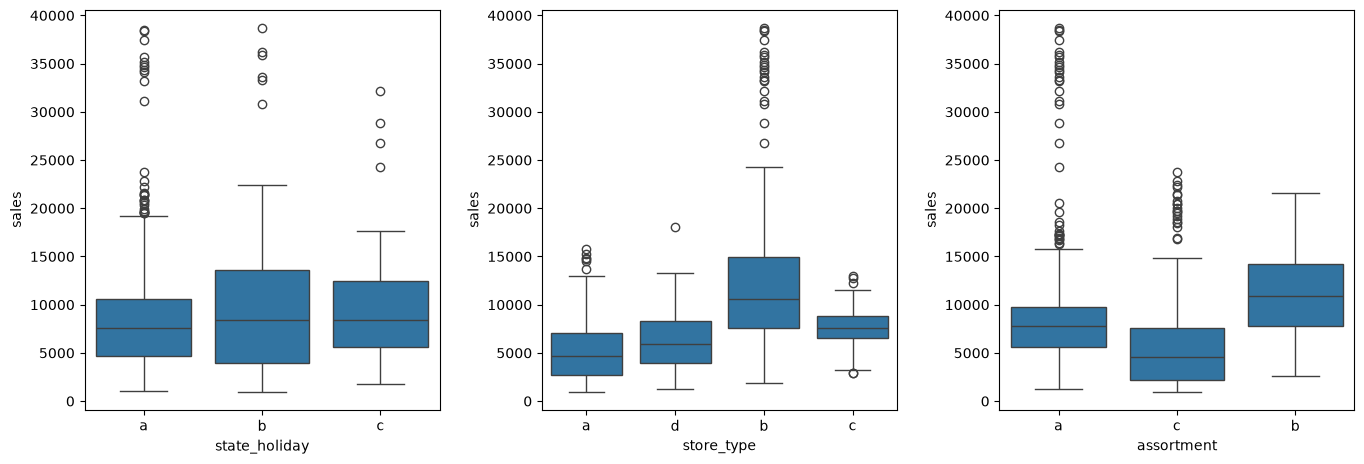

In [13]:
aux1 = df1[(df1['state_holiday'] !='0') & (df1['sales'] > 0)]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='state_holiday', y='sales', data=aux1)

plt.subplot(1, 3, 2)
sns.boxplot(x='store_type', y='sales', data=aux1)

plt.subplot(1, 3, 3)
sns.boxplot(x='assortment', y='sales', data=aux1)

plt.tight_layout(pad=2.0)
plt.show()

# 2.0 - Feature Engineering

In [14]:
df2 = df1.copy()

### 2.1 - Criação de Hipoteses (Alavancas)

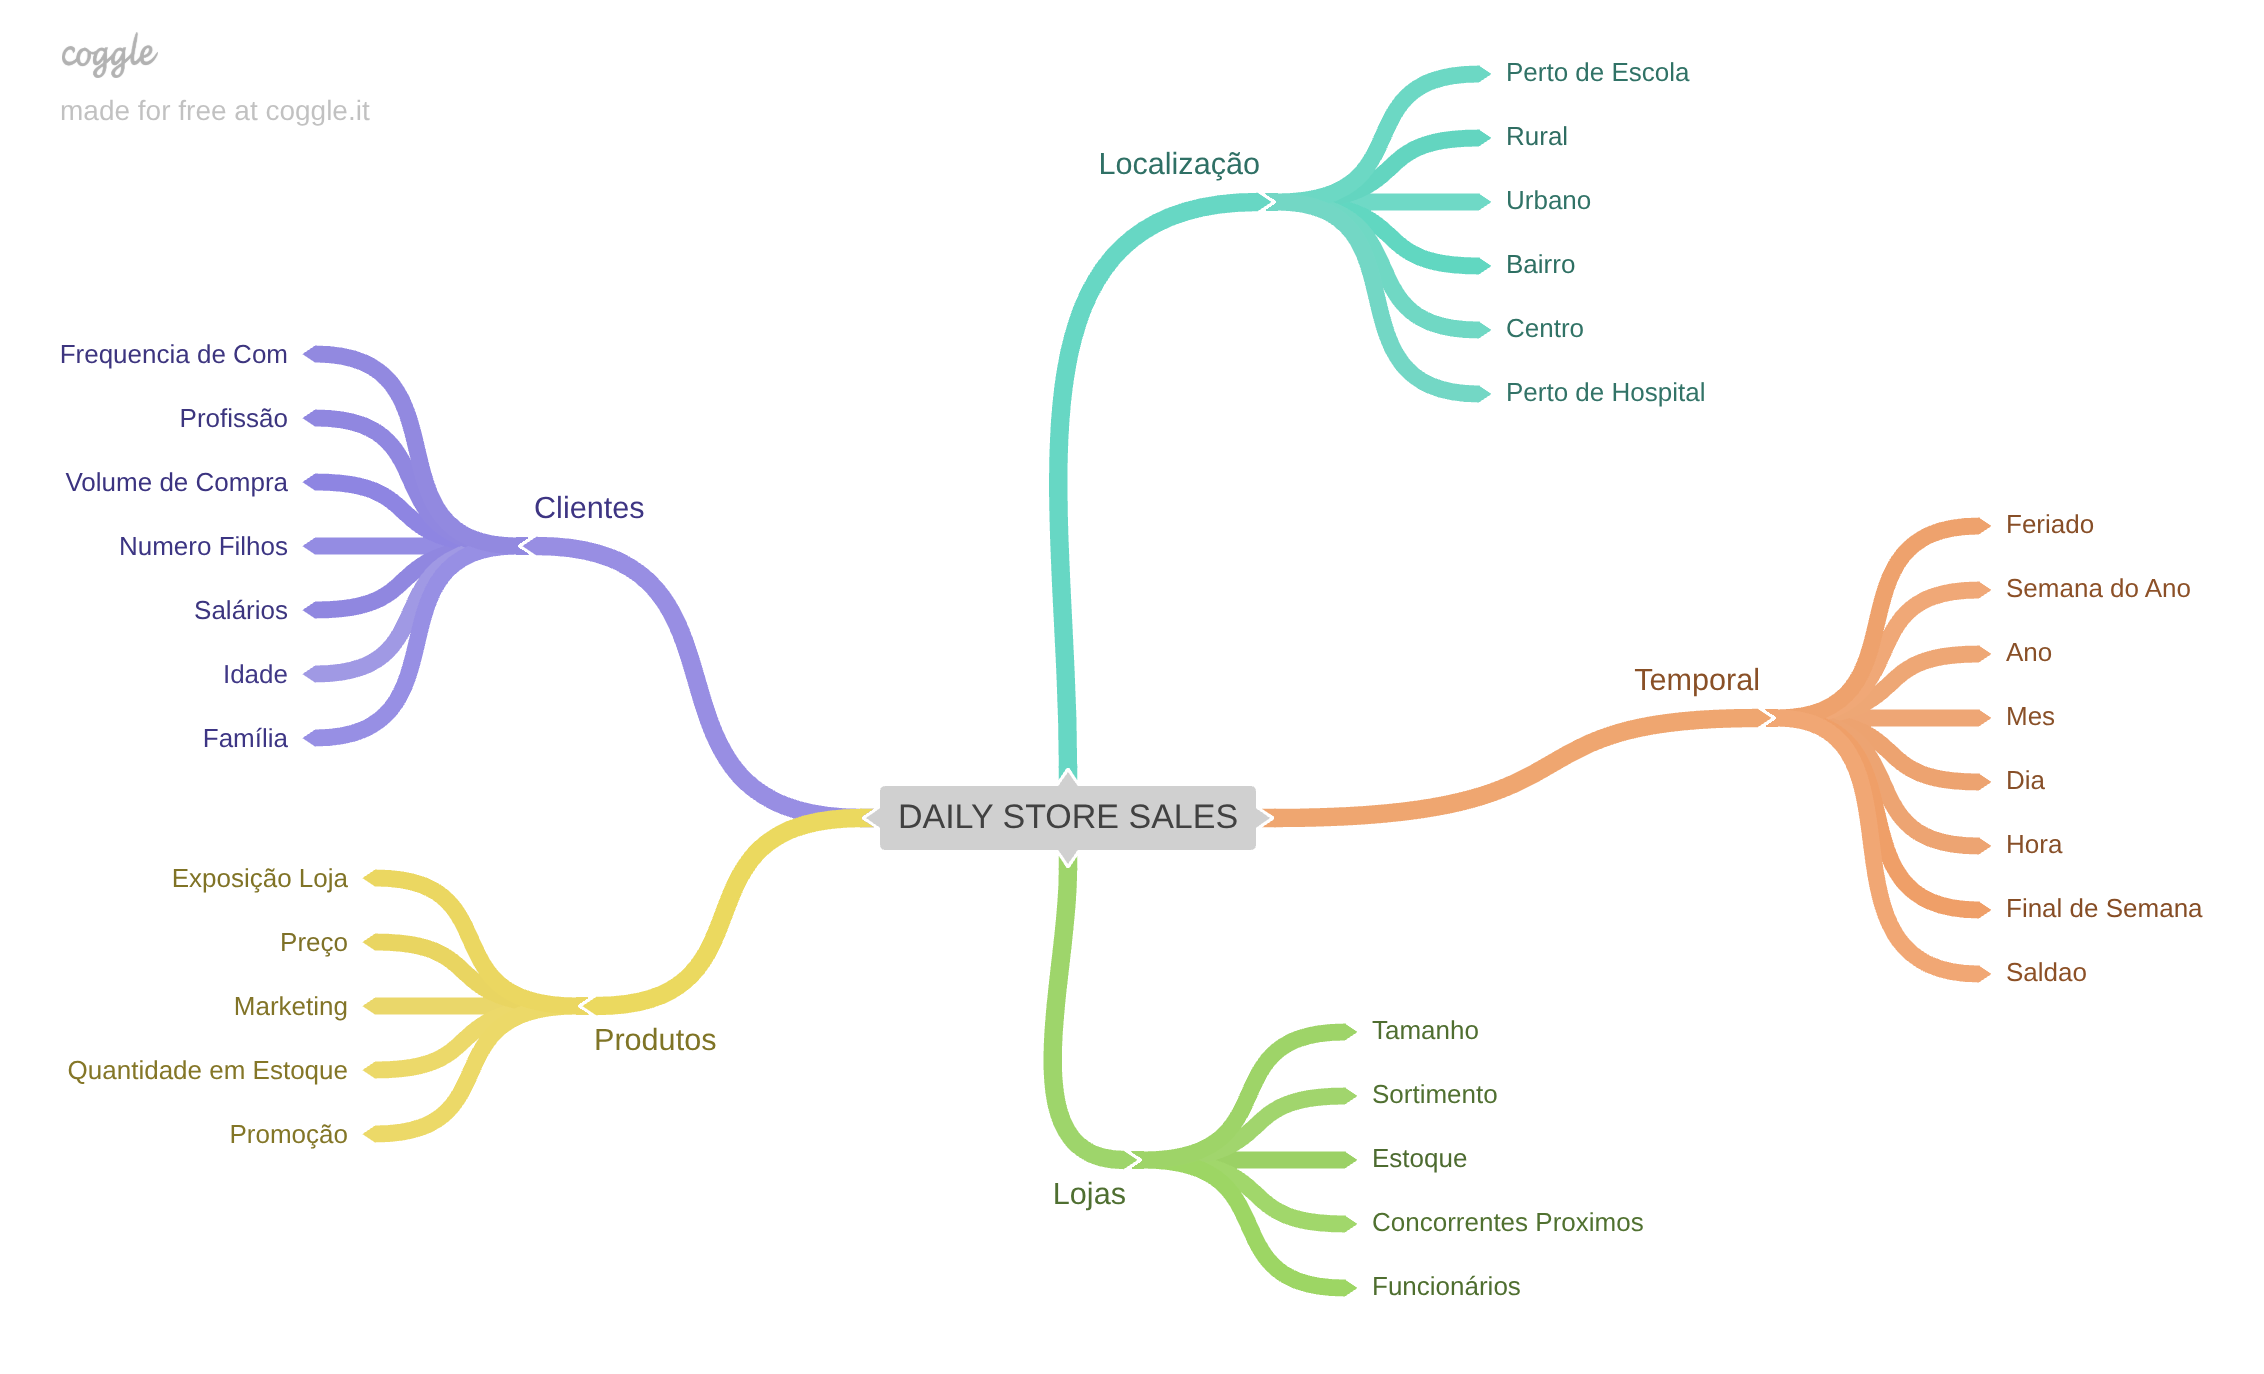

In [15]:
Image (mindmap)

#### 2.1.1 - Hipoteses Loja

**1.** - Lojas com maior quadro de funcionários deveriam vender mais

**2.** - Lojas com maior estoque deveriam vender mais

**3.** - Lojas com maior porte deveriam vender mais

**4.** - Lojas com menor porte deveriam vender menos

**5.** - Lojas com maior sortimento deveriam vender mais

#### 2.1.2 - Hipoteses Produto

**1.** - Lojas que investem mais em Marketing deveriam vender mais

**2.** - Lojas que expoem mais os produtos nas vitrines deveriam vender mais

**3.** - Lojas que tem preços menores nos produtos deveriam vender mais

**4.** - Lojas que tem preços menores por mais tempo nos produtos deveriam vender mais

#### 2.1.3 - Hipoteses Tempo

**1.** - Lojas que tem mais feriados deveriam vender menos (fechada ou fluxo)

**2.** - Lojas que abrem nos primeiros seis meses deveriam vender mais

**3.** - Lojas que abrem nos finais de semana deveriam vender mais

### 2.2 - Lista Final de Hipoteses

**1.** Lojas com maior sortimento deveriam vender mais

**2.** Lojas com competidores mais proximos deveriam vender menos

**3.** Lojas com competidores a mais tempo deveriam vender mais


**4.** Lojas com promoções ativas por mais tempo deveriam vender mais

**5.** Lojas com mais dias de promoção deveriam vender mais

**6.** Lojas com mais promoções deveriam vender mais

**7.** Lojas abertas durante o feriado de Natal deveriam vender mais

**8.** Lojas deveriam vender mais ao longo do tempo

**9.** Lojas deveriam vender mais no segundo semestre do ano

**10.** Lojas deveriam vender mais depois do dia 10 de cada mês

**11.** Lojas deveriam vender menos aos finais de semana

**12.** Lojas deveriam vender menos durante os feriados escolares

### 2.3 - Feature Engineering

In [16]:
# year
df2['year'] = df2['date'].dt.year

# month
df2['month'] = df2['date'].dt.month

# day
df2['day'] = df2['date'].dt.day

# week of year
df2['week_of_year'] = df2['date'].dt.isocalendar().week

#year week
df2['year_week'] = df2['date'].dt.strftime('%Y-%W')

# competition since
df2['competition_since'] = df2.apply(lambda x: datetime.datetime(year=x['competition_open_since_year'], month=x['competition_open_since_month'], day=1), axis=1)
df2['competition_time_month'] = ((df2['date'] - df2['competition_since']) / 30).apply(lambda x: x.days).astype(int)

# promo since
df2['promo_since'] = df2['promo2_since_year'].astype(str) + '-' + df2['promo2_since_week'].astype(str)
df2['promo_since'] = df2['promo_since'].apply(lambda x: datetime.datetime.strptime(x + '-1', '%Y-%W-%w')- datetime.timedelta(days=7))
df2['promo_time_week'] = ((df2['date'] - df2['promo_since']) / 7).apply(lambda x: x.days).astype(int)

# assortment
df2['assortment'] = df2['assortment'].apply(lambda x: 'basic' if x == 'a' else 'extra' if x == 'b' else 'extended')

# state holiday
df2['state_holiday'] = df2['state_holiday'].apply(lambda x: 'public_holiday' if x == 'a' else 'easter_holiday' if x == 'b' else 'christmas' if x == 'c' else 'regular_day')

# 3.0 - Filtragem de Variaveis

In [17]:
df3 = df2.copy()

In [18]:
df3.head()

,store,day_of_week,date,sales,customers,open,promo,state_holiday,school_holiday,store_type,...,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week
0,1,5,2015-07-31,5263,555,1,1,regular_day,1,c,...,0,2015,7,31,31,2015-30,2008-09-01,84,2015-07-27,0
1,2,5,2015-07-31,6064,625,1,1,regular_day,1,a,...,1,2015,7,31,31,2015-30,2007-11-01,94,2010-03-22,279
2,3,5,2015-07-31,8314,821,1,1,regular_day,1,a,...,1,2015,7,31,31,2015-30,2006-12-01,105,2011-03-28,226
3,4,5,2015-07-31,13995,1498,1,1,regular_day,1,c,...,0,2015,7,31,31,2015-30,2009-09-01,71,2015-07-27,0
4,5,5,2015-07-31,4822,559,1,1,regular_day,1,a,...,0,2015,7,31,31,2015-30,2015-04-01,4,2015-07-27,0


### 3.1 - Filtragem das Linhas

In [19]:
df3 = df3[(df3['open'] != 0) & (df3['sales'] > 0)]

### 3.2 - Seleção das Colunas

In [20]:
cols_drop = ['customers', 'open', 'promo_interval', 'month_map']
df3 = df3.drop(cols_drop, axis=1)

# 4.0 - Analise Exploratória de Dados (EDA)

In [21]:
df4 = df3.copy()

### 4.1 - Analise Univariada

#### 4.1.1 - Response Variable

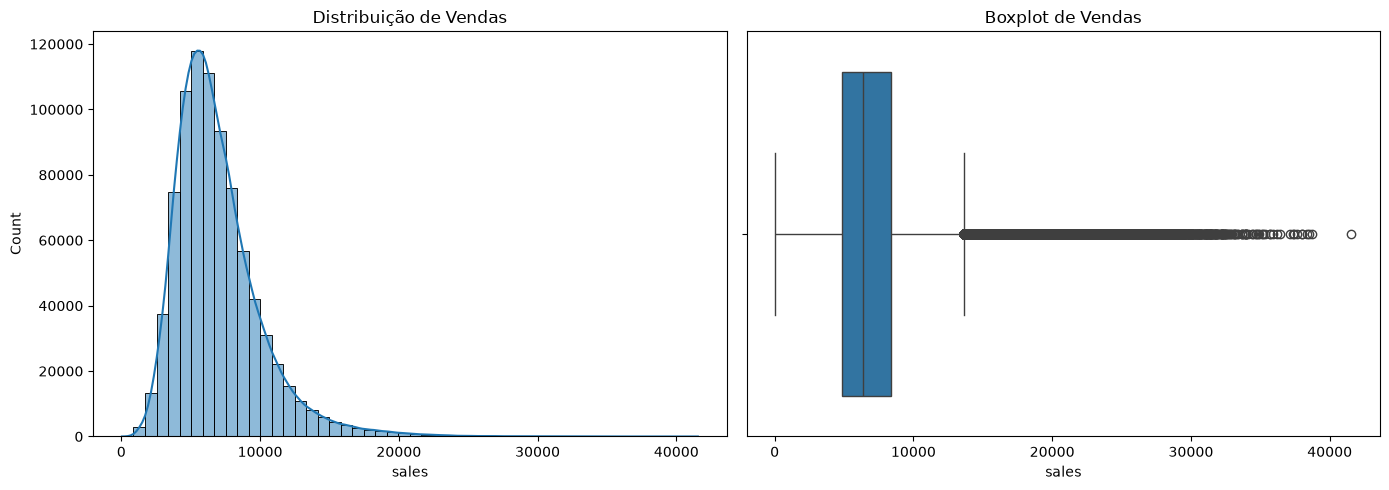

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df4['sales'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Vendas')

sns.boxplot(x=df4['sales'], ax=axes[1])
axes[1].set_title('Boxplot de Vendas')

plt.tight_layout()
plt.show()

#### 4.1.2 - Numerical Variable

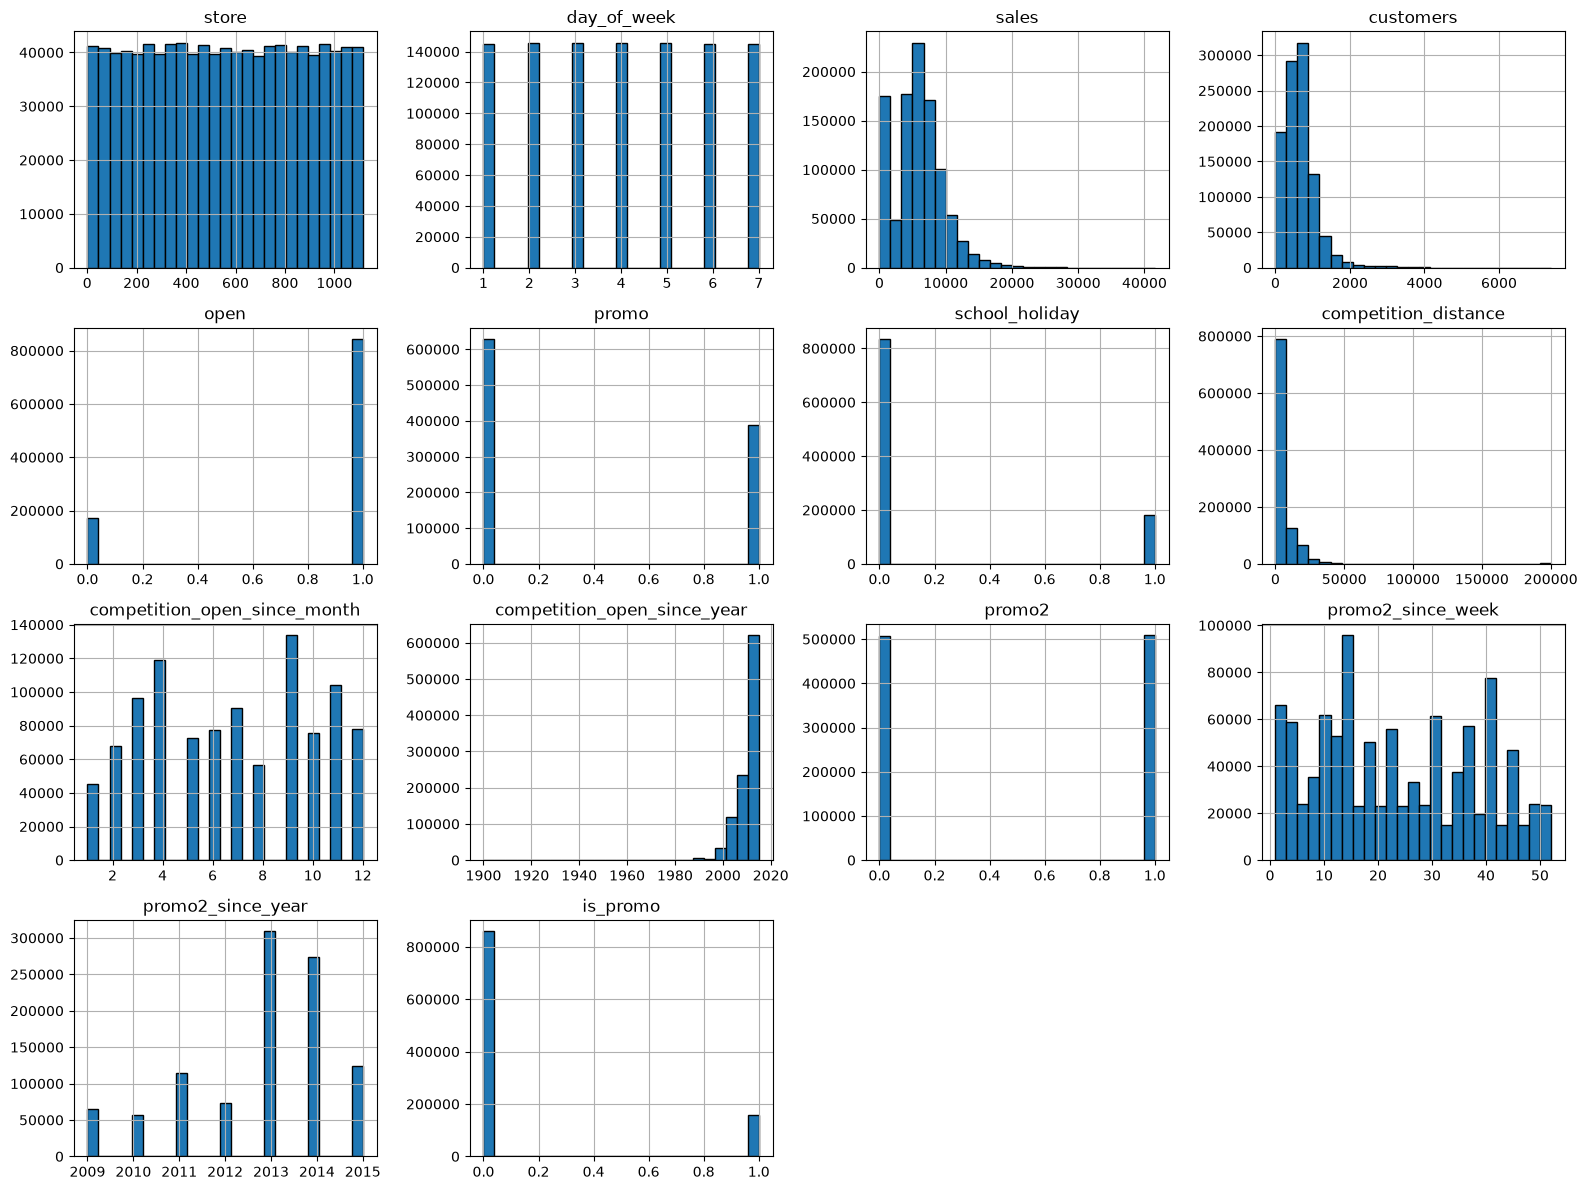

In [23]:
num_attributes.hist(figsize=(16, 12), bins=25, edgecolor='black')
plt.tight_layout()
plt.show()

#### 4.1.3 - Categorical Variable

In [24]:
df4['assortment'].drop_duplicates()

0         basic
3      extended
258       extra
Name: assortment, dtype: str

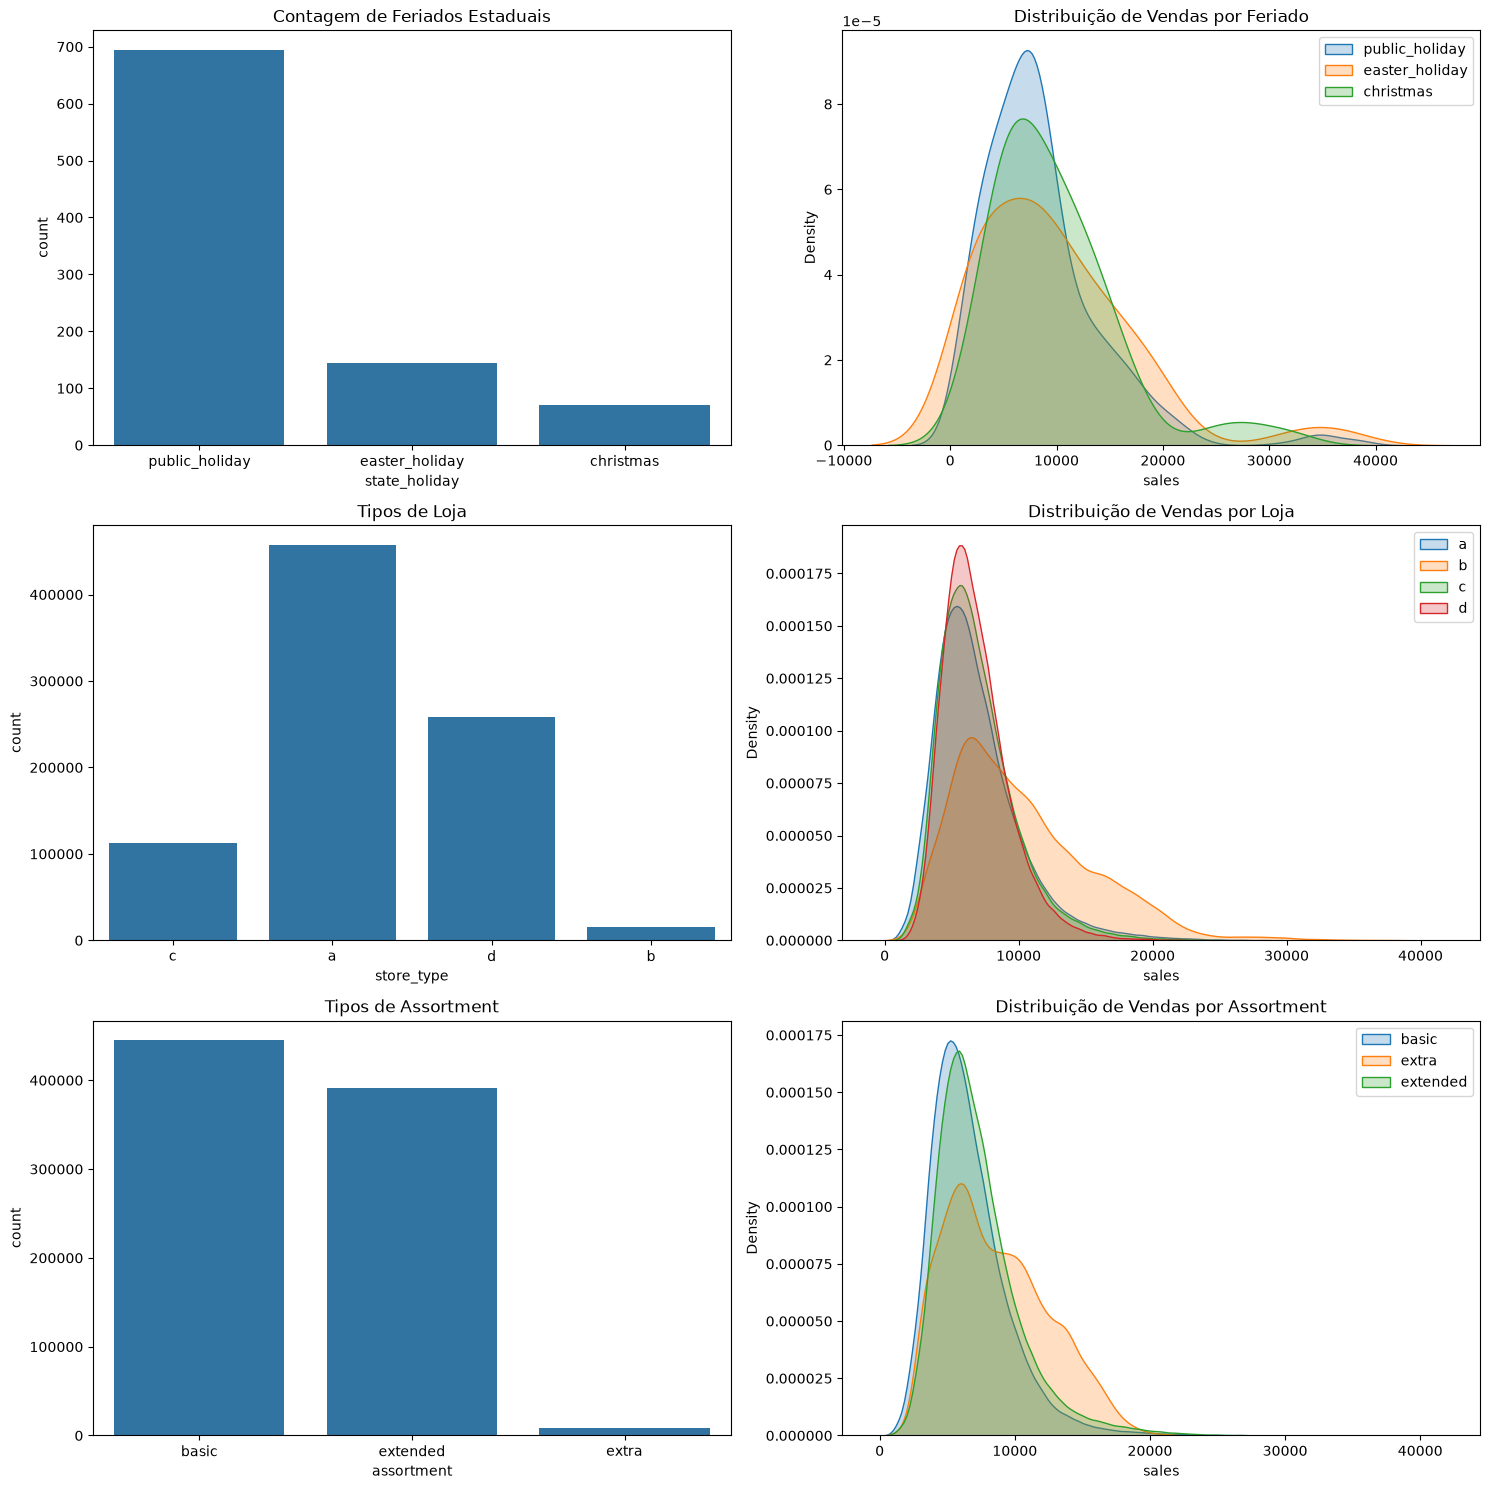

In [25]:
# Criando a matriz de gráficos 3x2
fig, ax = plt.subplots(3, 2, figsize=(15, 15))

# ==========================================
# 1. Ajuste dos Feriados (state_holiday)
# ==========================================
a = df4[df4['state_holiday'] != 'regular_day']
sns.countplot(data=a, x='state_holiday', ax=ax[0, 0])
ax[0, 0].set_title('Contagem de Feriados Estaduais')

sns.kdeplot(df4[df4['state_holiday'] == 'public_holiday']['sales'], label='public_holiday', fill=True, ax=ax[0, 1])
sns.kdeplot(df4[df4['state_holiday'] == 'easter_holiday']['sales'], label='easter_holiday', fill=True, ax=ax[0, 1])
sns.kdeplot(df4[df4['state_holiday'] == 'christmas']['sales'], label='christmas', fill=True, ax=ax[0, 1])

ax[0, 1].set_title('Distribuição de Vendas por Feriado')
ax[0, 1].legend()

# ==========================================
# 2. Ajuste dos Tipos de Loja (store_type)
# ==========================================
sns.countplot(data=df4, x='store_type', ax=ax[1, 0]) 
ax[1, 0].set_title('Tipos de Loja')

sns.kdeplot(df4[df4['store_type'] == 'a']['sales'], label='a', fill=True, ax=ax[1, 1])
sns.kdeplot(df4[df4['store_type'] == 'b']['sales'], label='b', fill=True, ax=ax[1, 1])
sns.kdeplot(df4[df4['store_type'] == 'c']['sales'], label='c', fill=True, ax=ax[1, 1])
sns.kdeplot(df4[df4['store_type'] == 'd']['sales'], label='d', fill=True, ax=ax[1, 1])

ax[1, 1].set_title('Distribuição de Vendas por Loja')
ax[1, 1].legend()

# ==========================================
# 3. Ajuste dos Tipos de Assortment (Assortment)
# ==========================================
sns.countplot(data=df4, x='assortment', ax=ax[2, 0]) 
ax[2, 0].set_title('Tipos de Assortment')

sns.kdeplot(df4[df4['assortment'] == 'basic']['sales'], label='basic', fill=True, ax=ax[2, 1])
sns.kdeplot(df4[df4['assortment'] == 'extra']['sales'], label='extra', fill=True, ax=ax[2, 1])
sns.kdeplot(df4[df4['assortment'] == 'extended']['sales'], label='extended', fill=True, ax=ax[2, 1])

ax[2, 1].set_title('Distribuição de Vendas por Assortment')
ax[2, 1].legend()


# ==========================================
# 4. Mostra os graficos finais
# ========================================== 
plt.tight_layout()
plt.show()

### 4.2 - Analise Bivariada

#### **H1.** Lojas com maior sortimentos deveriam vender mais

**FALSE** Lojas com MAIORES SORTIMENTOS vendem MENOS

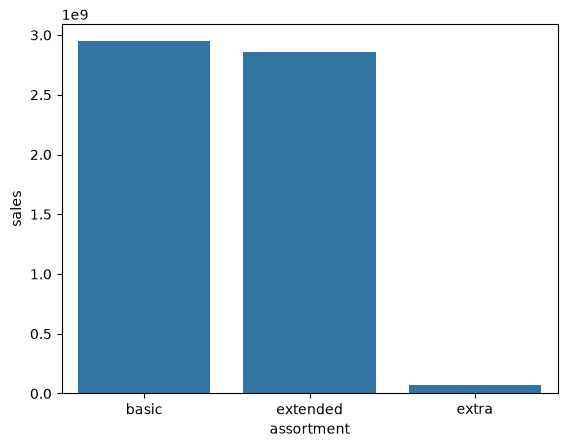

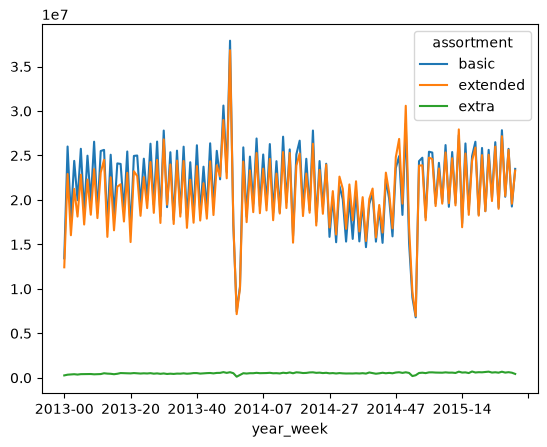

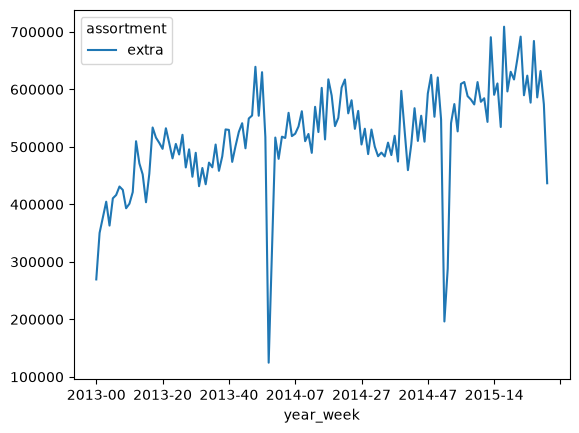

In [ ]:
# ==========================================
# 1. Assortment (Assortment) x vendas
# ==========================================

aux1 = df4[['assortment', 'sales']].groupby('assortment').sum().reset_index()
sns.barplot(x='assortment', y='sales', data=aux1, errorbar=None);
plt.show()

# ==========================================
# 2. Assortment (Assortment) por semanas do ano x vendas
# ==========================================
aux2 = (df4[['year_week', 'assortment', 'sales']]
        .groupby(['year_week', 'assortment'])
        .sum()
        .reset_index())
aux2.pivot(index='year_week', columns='assortment', values='sales').plot()
plt.show()

# ==========================================
# 3. Assortment (Assortment) = Extra
# ==========================================
aux3 = aux2[aux2['assortment'] == 'extra']
aux3.pivot(index='year_week', columns='assortment', values='sales').plot()
plt.show()

#### **H2.** Lojas com competidores mais proximos deveriam vender menos

**FALSE** Lojas com COMPETIDORES MAIS PROXIMOS vendem MAIS

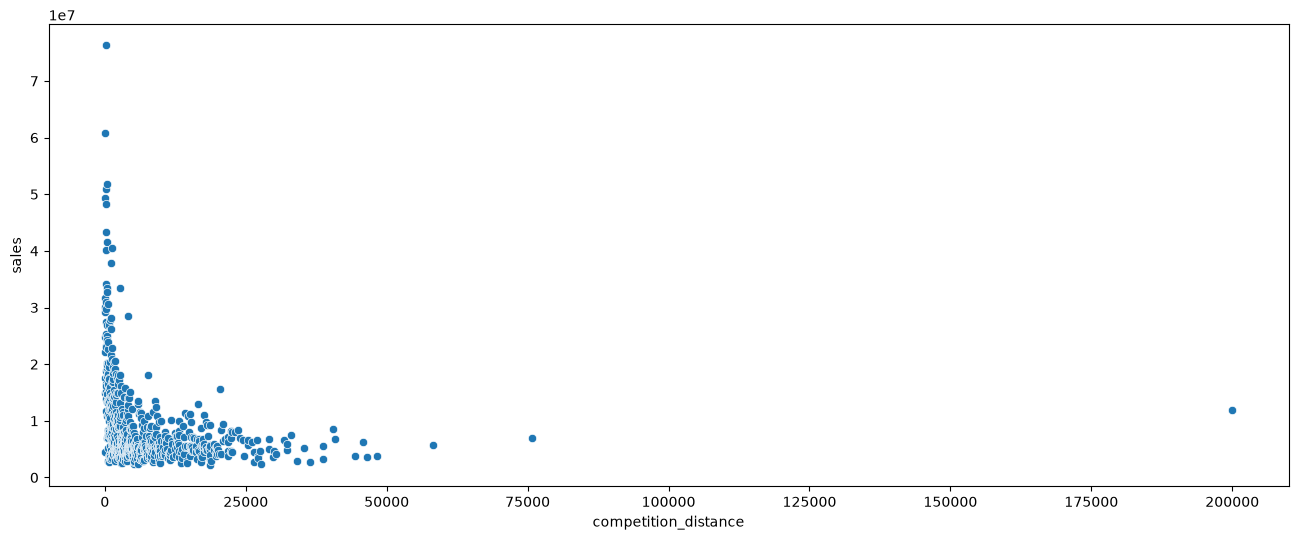

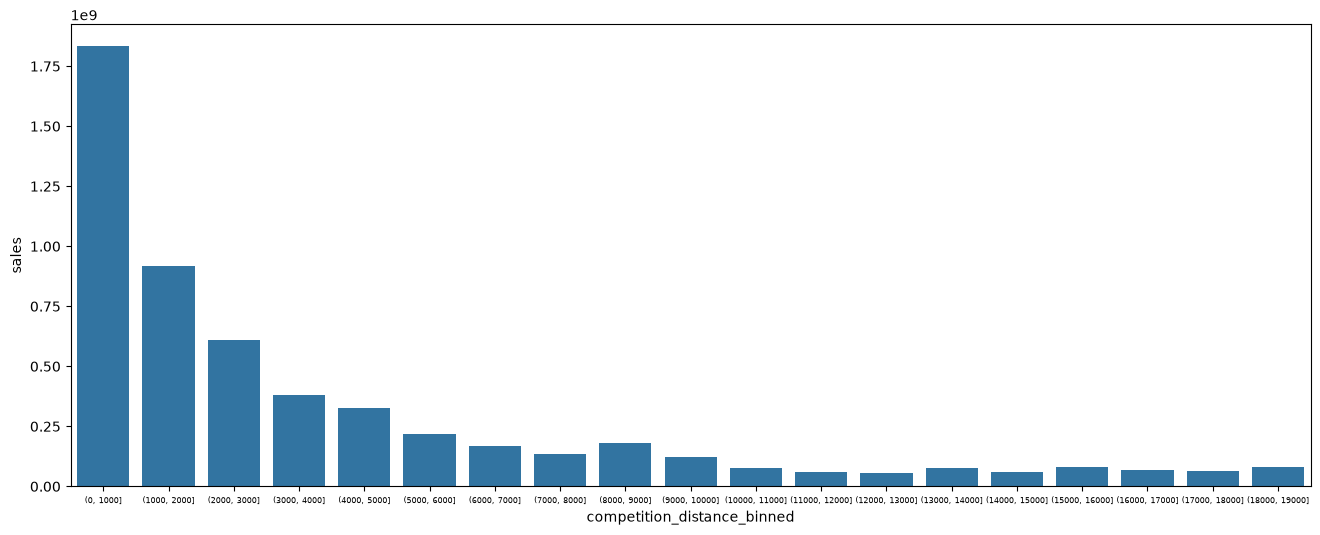

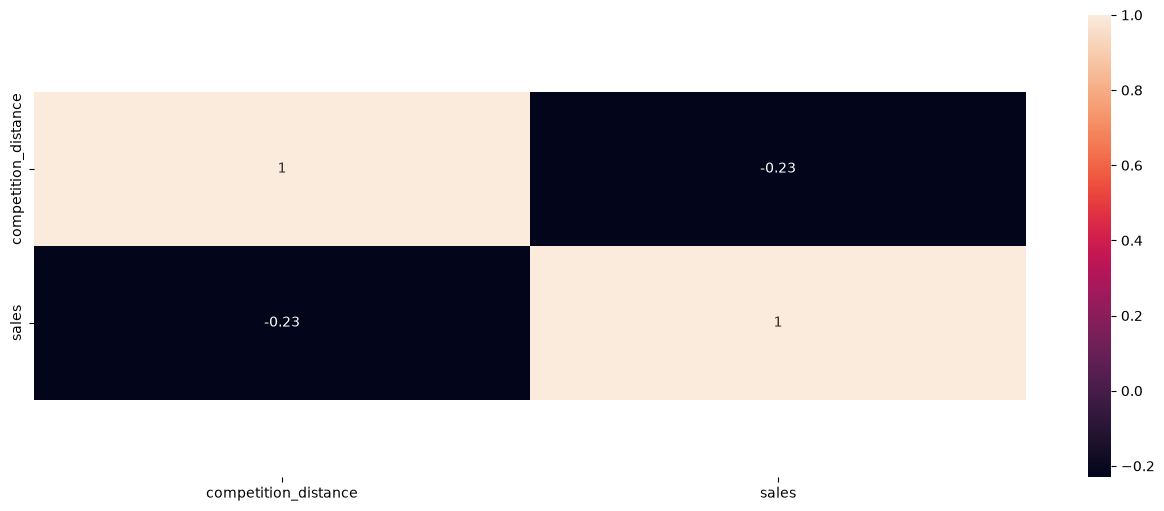

In [51]:
aux1 = df4[['competition_distance', 'sales']].groupby('competition_distance').sum().reset_index()

# ==========================================
# 1. Scatter Plot com as Vendas pela Distancia dos Concorrentes
# ==========================================

plt.figure(figsize=(16, 6))
sns.scatterplot(x = 'competition_distance', y = 'sales', data=aux1)
plt.show()

# ==========================================
# 2. Histograma com as Vendas pela Distancia dos Concorrentes (em Range)
# ==========================================

bins = list(np.arange(0, 20000, 1000))
aux1['competition_distance_binned'] = pd.cut(aux1['competition_distance'], bins=bins)
aux2 = aux1[['competition_distance_binned', 'sales']].groupby('competition_distance_binned').sum().reset_index()

plt.figure(figsize=(16, 6))
sns.barplot(x='competition_distance_binned', y='sales', data=aux2, errorbar=None)
plt.xticks(fontsize=6)
plt.show()

# ==========================================
# 3. Correlação entre Distancia dos Concorrentes e as Vendas
# ==========================================
plt.figure(figsize=(16, 6))
x = sns.heatmap(
    aux1[['competition_distance', 'sales']].corr(method='pearson'),
    annot=True
)
bottom, top = x.get_ylim()
x.set_ylim(bottom + 0.5, top - 0.5)
plt.show()

#### **H3.** Lojas com competidores à mais tempo deveriam vender mais

**FALSE** Lojas com COMPETIDORES A MAIS TEMPO vendem MENOS

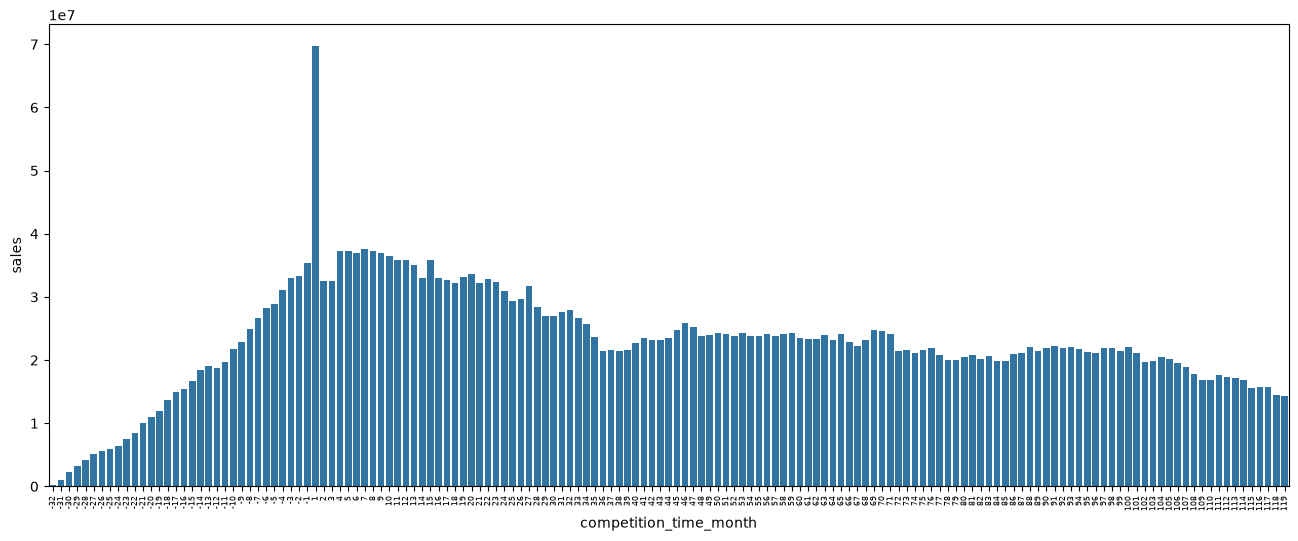

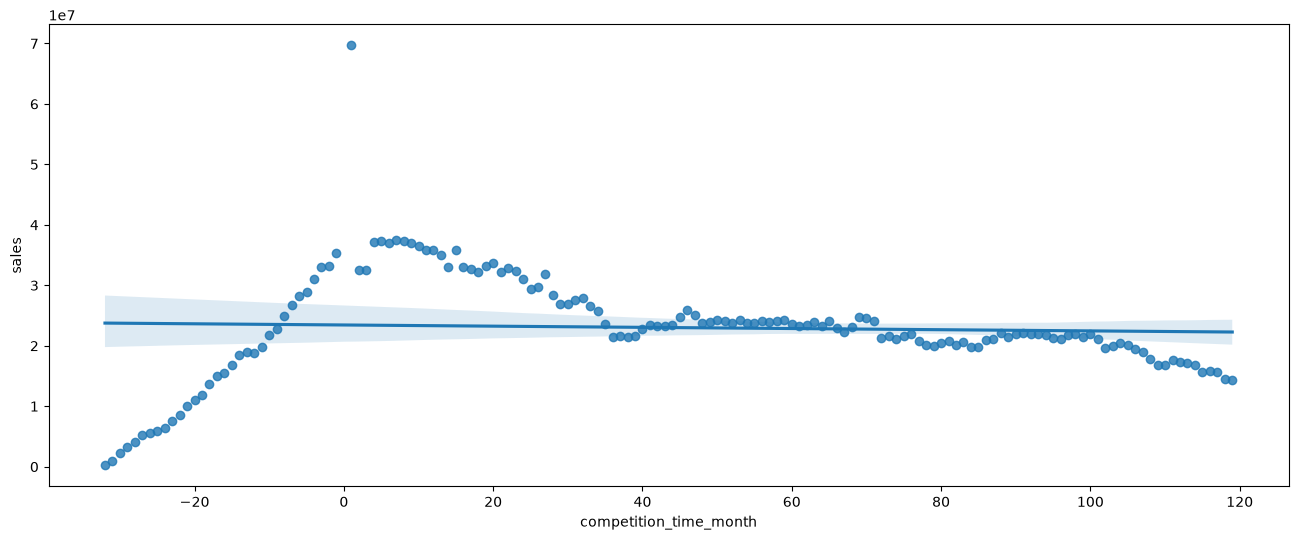

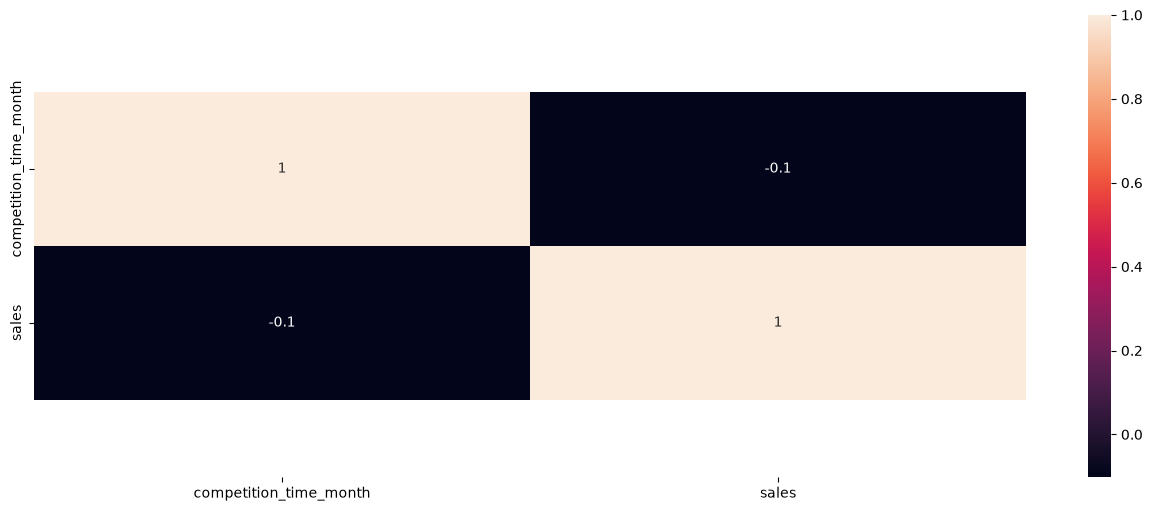

In [61]:
aux1 = df4[['competition_time_month', 'sales']].groupby('competition_time_month').sum().reset_index()
aux2 = aux1[(aux1['competition_time_month'] < 120) & (aux1['competition_time_month'] != 0)]
plt.figure(figsize=(16, 6))
sns.barplot(x='competition_time_month', y='sales', data=aux2)
plt.xticks(fontsize=6, rotation = 90)
plt.show()

plt.figure(figsize=(16, 6))
sns.regplot(x='competition_time_month', y='sales', data=aux2)
plt.show()

plt.figure(figsize=(16, 6))
x = sns.heatmap(
    aux1[['competition_time_month', 'sales']].corr(method='pearson'),
    annot=True
)
bottom, top = x.get_ylim()
x.set_ylim(bottom + 0.5, top - 0.5)
plt.show()

#### **H4.** Lojas com promoções ativas por mais tempo deveriam vender mais

**False** - Lojas com promoções ativas por mais tempo vendem menos, depois de um certo periodo de promoção

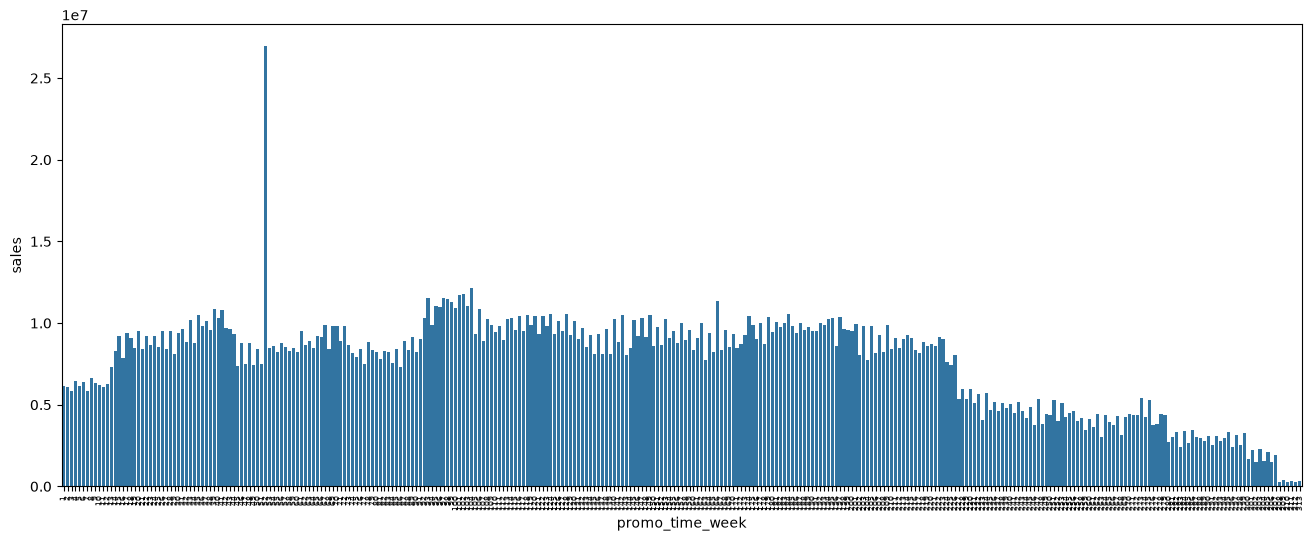

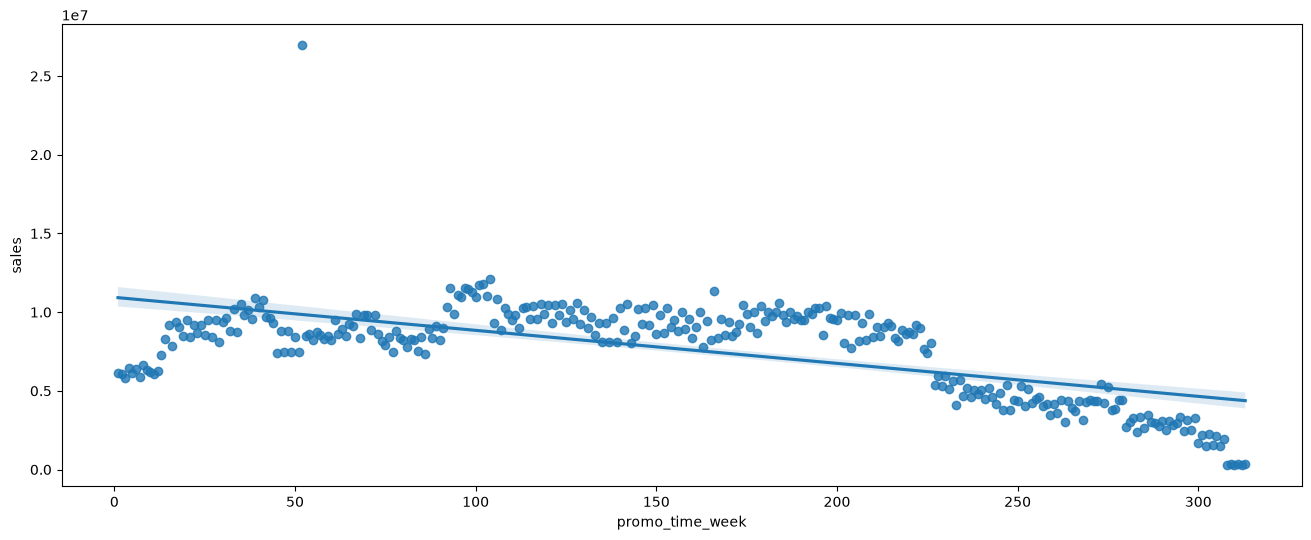

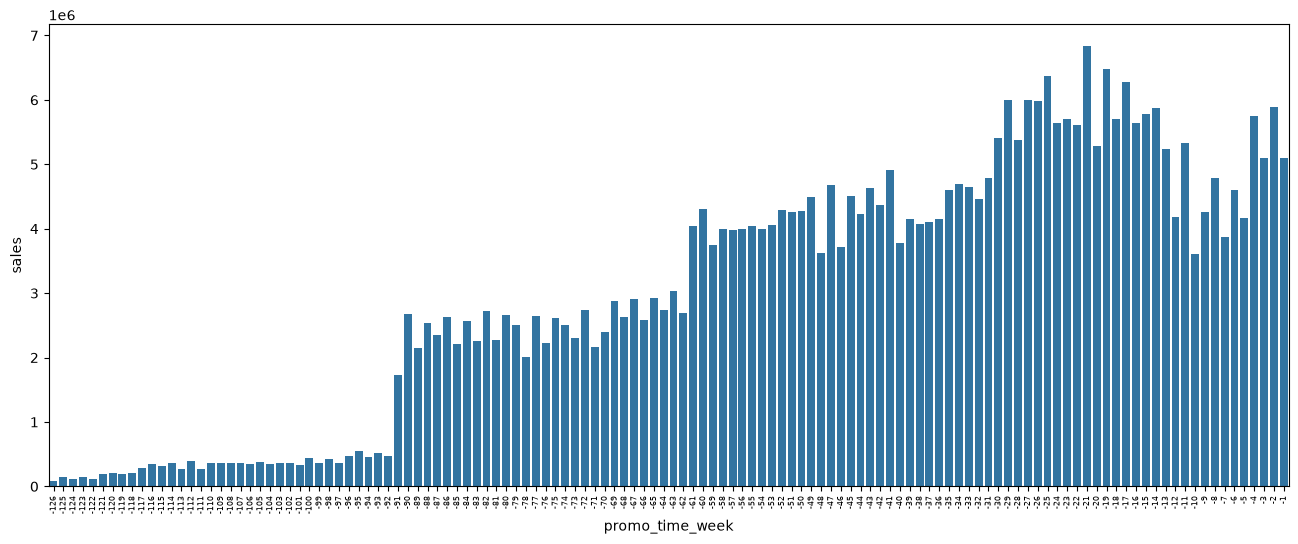

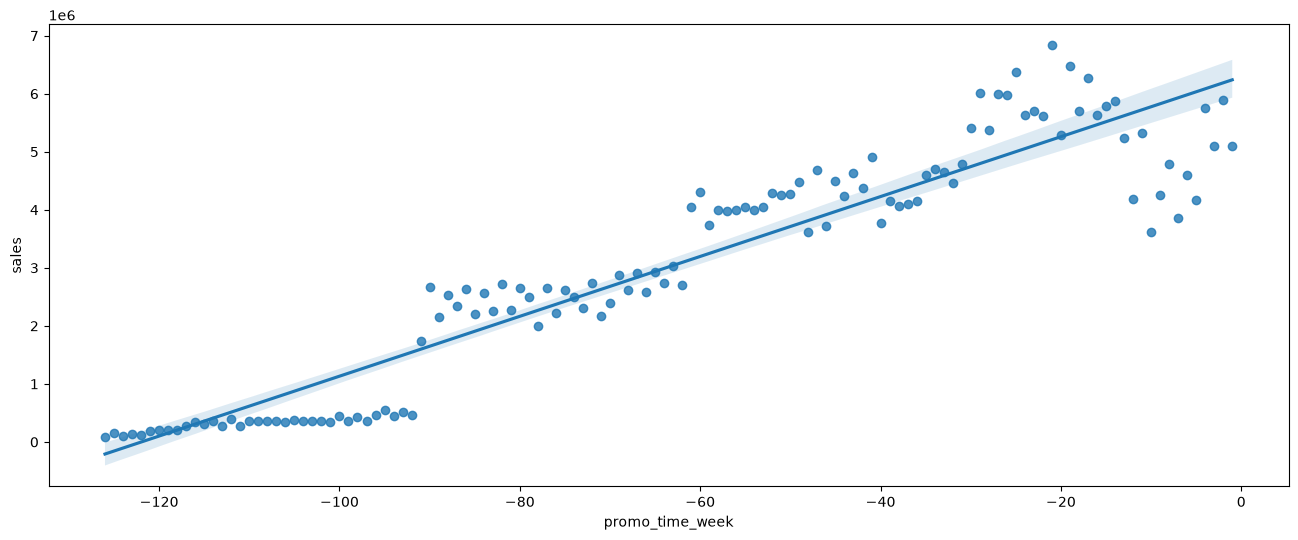

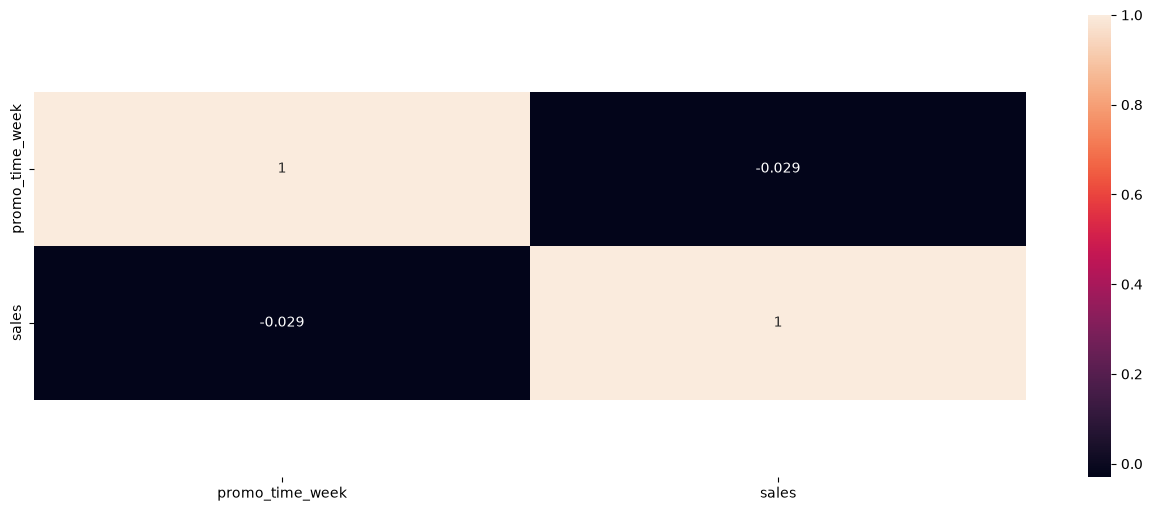

In [73]:
aux1 = df4[['promo_time_week','sales']].groupby('promo_time_week').sum().reset_index()

plt.figure(figsize=(16, 6))
aux2 = aux1[aux1['promo_time_week']> 0] # promo extendido
sns.barplot(x='promo_time_week', y='sales', data=aux2);
plt.xticks(fontsize=6, rotation = 90)
plt.show()

plt.figure(figsize=(16, 6))
sns.regplot(x='promo_time_week', y='sales', data=aux2);
plt.show()

plt.figure(figsize=(16, 6))
aux3 = aux1[aux1['promo_time_week']< 0] # promo regular
sns.barplot(x='promo_time_week', y='sales', data=aux3);
plt.xticks(fontsize=6, rotation = 90)
plt.show()

plt.figure(figsize=(16, 6))
sns.regplot(x='promo_time_week', y='sales', data=aux3);
plt.show()

plt.figure(figsize=(16, 6))
x = sns.heatmap(
    aux1[['promo_time_week', 'sales']].corr(method='pearson'),
    annot=True
)
bottom, top = x.get_ylim()
x.set_ylim(bottom + 0.5, top - 0.5)
plt.show()


#### <s>**H5.** Lojas com mais dias de promoção deveriam vender mais</s>

#### **H6.** Lojas com mais promoções consecutivas deveriam vender mais